In [1]:
import pandas as pd

In [2]:
import sys
sys.executable

'c:\\Users\\UlrichLehre\\Documents\\Weather_Study\\.venv\\Scripts\\python.exe'

In [2]:
from pathlib import Path
Path.cwd()

WindowsPath('c:/Users/UlrichLehre/Documents/Weather_Study/notebooks')

In [3]:
import requests
import pandas as pd

META_URL = "https://dataset.api.hub.geosphere.at/v1/station/historical/klima-v2-10min/metadata"
meta = requests.get(META_URL, timeout=60).json()

# einmal schauen, wie das JSON aufgebaut ist
meta.keys()

dict_keys(['stations', 'parameters', 'title', 'frequency', 'type', 'mode', 'response_formats', 'start_time', 'end_time', 'id_type', 'code_lists'])

In [4]:
stations = meta.get('stations')
print(stations)

[{'type': 'COMBINED', 'id': 1, 'group_id': None, 'name': 'Aflenz', 'state': 'Steiermark', 'lat': 47.54594, 'lon': 15.24069, 'altitude': 783.2, 'valid_from': '1983-05-01T00:00:00+00:00', 'valid_to': '2100-12-31T00:00:00+00:00', 'has_sunshine': True, 'has_global_radiation': True, 'is_active': True}, {'type': 'COMBINED', 'id': 2, 'group_id': None, 'name': 'Aigen im Ennstal', 'state': 'Steiermark', 'lat': 47.53278, 'lon': 14.13826, 'altitude': 641.0, 'valid_from': '1993-02-01T00:00:00+00:00', 'valid_to': '2100-12-31T00:00:00+00:00', 'has_sunshine': True, 'has_global_radiation': True, 'is_active': True}, {'type': 'COMBINED', 'id': 3, 'group_id': None, 'name': 'Allentsteig', 'state': 'Niederösterreich', 'lat': 48.69083, 'lon': 15.36694, 'altitude': 598.8, 'valid_from': '1992-10-01T00:00:00+00:00', 'valid_to': '2100-12-31T00:00:00+00:00', 'has_sunshine': True, 'has_global_radiation': True, 'is_active': True}, {'type': 'COMBINED', 'id': 4, 'group_id': None, 'name': 'Amstetten', 'state': 'Niede

In [21]:
code_lists = meta.get('code_lists')
print(code_lists)

{'q21': [{'key': None, 'value': 'undefiniert'}, {'key': 0, 'value': 'ungeprüfte Daten'}, {'key': 10, 'value': 'automatisch geprüft'}, {'key': 11, 'value': 'automatisch geprüft (verändert)'}, {'key': 12, 'value': 'automatisch geprüft (original)'}, {'key': 20, 'value': 'manuell geprüft (unbekannt)'}, {'key': 21, 'value': 'manuell geprüft (verändert)'}, {'key': 22, 'value': 'manuell geprüft (original)'}], 'c1': [{'key': 0, 'value': 'kein Niederschlag gemessen'}, {'key': 1, 'value': 'Niederschlag gemessen'}]}


In [20]:
df_stations = pd.DataFrame(stations)
df_stations

,type,id,group_id,name,state,lat,lon,altitude,valid_from,valid_to,has_sunshine,has_global_radiation,is_active
0,COMBINED,1,NaN,Aflenz,Steiermark,47.54594,15.24069,783.2,1983-05-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
1,COMBINED,2,NaN,Aigen im Ennstal,Steiermark,47.53278,14.13826,641.0,1993-02-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
2,COMBINED,3,NaN,Allentsteig,Niederösterreich,48.69083,15.36694,598.8,1992-10-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
3,COMBINED,4,NaN,Amstetten,Niederösterreich,48.10889,14.89500,266.0,1993-02-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
4,COMBINED,5,NaN,Bad Aussee,Steiermark,47.61050,13.75844,743.1,1983-09-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,INDIVIDUAL,20901,11.0,Bad Radkersburg,Steiermark,46.68667,15.97861,208.0,1992-08-29T00:10:00+00:00,2000-06-08T00:00:00+00:00,True,False,False
522,INDIVIDUAL,20902,11.0,Bad Radkersburg,Steiermark,46.68583,15.97944,209.8,2001-02-22T10:10:00+00:00,2016-04-07T00:00:00+00:00,True,True,False
523,INDIVIDUAL,20903,11.0,Bad Radkersburg,Steiermark,46.69222,15.99333,207.0,2016-04-07T00:10:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
524,INDIVIDUAL,21101,206.0,Loibl Tunnel,Kärnten,46.44389,14.24917,1096.9,2006-01-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True


In [11]:
df_lienz = df_stations[df_stations['name'].str.contains("lienz", case=False, na=False)].copy()
df_lienz

,type,id,group_id,name,state,lat,lon,altitude,valid_from,valid_to,has_sunshine,has_global_radiation,is_active
49,COMBINED,55,NaN,Lienz,Tirol,46.82555,12.80639,661.0,1985-12-01T00:00:00+00:00,2100-12-31T00:00:00+00:00,True,True,True
480,INDIVIDUAL,17901,55.0,Lienz,Tirol,46.82555,12.80639,661.0,1992-08-29T00:10:00+00:00,2100-12-31T00:00:00+00:00,True,True,True


In [15]:
lienz_id = df_lienz.iloc[1]['id']
print(f' Die id ist :{lienz_id})

SyntaxError: unterminated f-string literal (detected at line 2) (2652198611.py, line 2)

In [12]:
from datetime import datetime, timedelta


In [16]:
BASE = "https://dataset.api.hub.geosphere.at/v1/station/historical/klima-v2-10min"

params = ["TL", "RF", "P", "FFAM", "FFX", "RR"]  # Temperatur, rel. Feuchte, Druck, Wind, Böen, Niederschlag (anpassen)

end = datetime.now()
start = end - timedelta(days=2)

q = {
    "station_ids": lienz_id,
    "parameters": ",".join(params),
    "start": start.strftime("%Y-%m-%dT%H:%M"),
    "end": end.strftime("%Y-%m-%dT%H:%M"),
    # optional, falls unterstützt:
    # "output_format": "json"
}

r = requests.get(BASE, params=q, timeout=120)
r.raise_for_status()
data = r.json()
data.keys()

dict_keys(['media_type', 'type', 'version', 'timestamps', 'features'])

In [19]:
data.keys()

dict_keys(['media_type', 'type', 'version', 'timestamps', 'features'])

In [26]:
data['features']

[{'type': 'Feature',
  'geometry': {'type': 'Point', 'coordinates': [46.82555, 12.80639]},
  'properties': {'parameters': {'ffam': {'name': 'Windgeschwindigkeit 10m, arithmetischer Mittelwert',
     'unit': 'm/s',
     'data': [0.6,
      0.6,
      0.6,
      1.0,
      1.5,
      1.3,
      1.0,
      1.2,
      0.7,
      0.6,
      1.0,
      1.2,
      1.2,
      1.4,
      1.5,
      1.3,
      0.9,
      1.0,
      0.7,
      0.6,
      0.3,
      0.9,
      0.8,
      0.7,
      1.0,
      0.5,
      0.8,
      1.3,
      1.0,
      0.6,
      1.2,
      1.4,
      1.2,
      0.8,
      0.4,
      0.4,
      0.3,
      0.4,
      0.6,
      0.4,
      0.7,
      0.5,
      0.3,
      0.4,
      0.7,
      0.3,
      0.6,
      1.2,
      0.7,
      0.5,
      0.9,
      0.9,
      0.6,
      0.7,
      1.2,
      1.2,
      1.3,
      0.7,
      1.1,
      1.1,
      0.9,
      0.7,
      1.0,
      1.3,
      1.5,
      1.1,
      0.8,
      0.9,
      0.7,
      1.3,
      1.

In [27]:
params = data["features"][0]["properties"]["parameters"]

params.keys()

dict_keys(['ffam', 'ffx', 'p', 'rf', 'rr', 'tl'])

In [28]:
time_index = pd.to_datetime(data["timestamps"])

In [29]:
time_index = time_index.tz_convert("Europe/Vienna")

In [31]:
df = pd.DataFrame(index=time_index)

for key, p in params.items():
    name = p["name"]
    unit = p["unit"]
    df[f"{name} ({unit})"] = p["data"]

df.head()

,"Windgeschwindigkeit 10m, arithmetischer Mittelwert (m/s)",Maximale Windgeschwindigkeit (Spitzenböe) (m/s),Luftdruck (hPa),Relative Feuchte (%),Niederschlagssumme (mm),Lufttemperatur 2m (°C)
2026-02-27 20:10:00+01:00,0.6,1.0,945.7,77.0,0.0,2.3
2026-02-27 20:20:00+01:00,0.6,1.0,945.7,78.0,0.0,2.0
2026-02-27 20:30:00+01:00,0.6,1.1,945.9,79.0,0.0,1.6
2026-02-27 20:40:00+01:00,1.0,1.6,945.9,79.0,0.0,1.6
2026-02-27 20:50:00+01:00,1.5,2.6,946.0,80.0,0.0,1.7


In [34]:
import matplotlib.pyplot as plt


def plot_dual_subplots(
    df,
    pairs,
    figsize=(12, 6),
    sharex=True,
    lw_left=1.8,
    lw_right=1.5,
):
    """
    pairs : list of tuples
        [(left_column, right_column), ...]
    """

    n = len(pairs)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=figsize,
        sharex=sharex,
        constrained_layout=True,
    )

    # falls nur ein subplot
    if n == 1:
        axes = [axes]

    for ax, (left_col, right_col) in zip(axes, pairs):

        # --- linke Achse ---
        ax.plot(df.index, df[left_col], label=left_col, linewidth=lw_left)
        ax.set_ylabel(left_col)
        ax.grid(True, alpha=0.3)

        # --- rechte Achse ---
        ax_r = ax.twinx()
        ax_r.plot(
            df.index,
            df[right_col],
            linestyle="--",
            linewidth=lw_right,
            color="orange",          # ← Linie
        )

        ax_r.set_ylabel(right_col, color="orange")  # ← Label-Farbe

        ax_r.tick_params(axis="y", colors="orange") # ← Tick-Farbe

        ax_r.spines["right"].set_color("orange")    # ← Achsenlinie
        ax_r.set_ylabel(right_col)

        # --- gemeinsame Legende ---
        lines = ax.get_lines() + ax_r.get_lines()
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc="upper left")

    return fig, axes

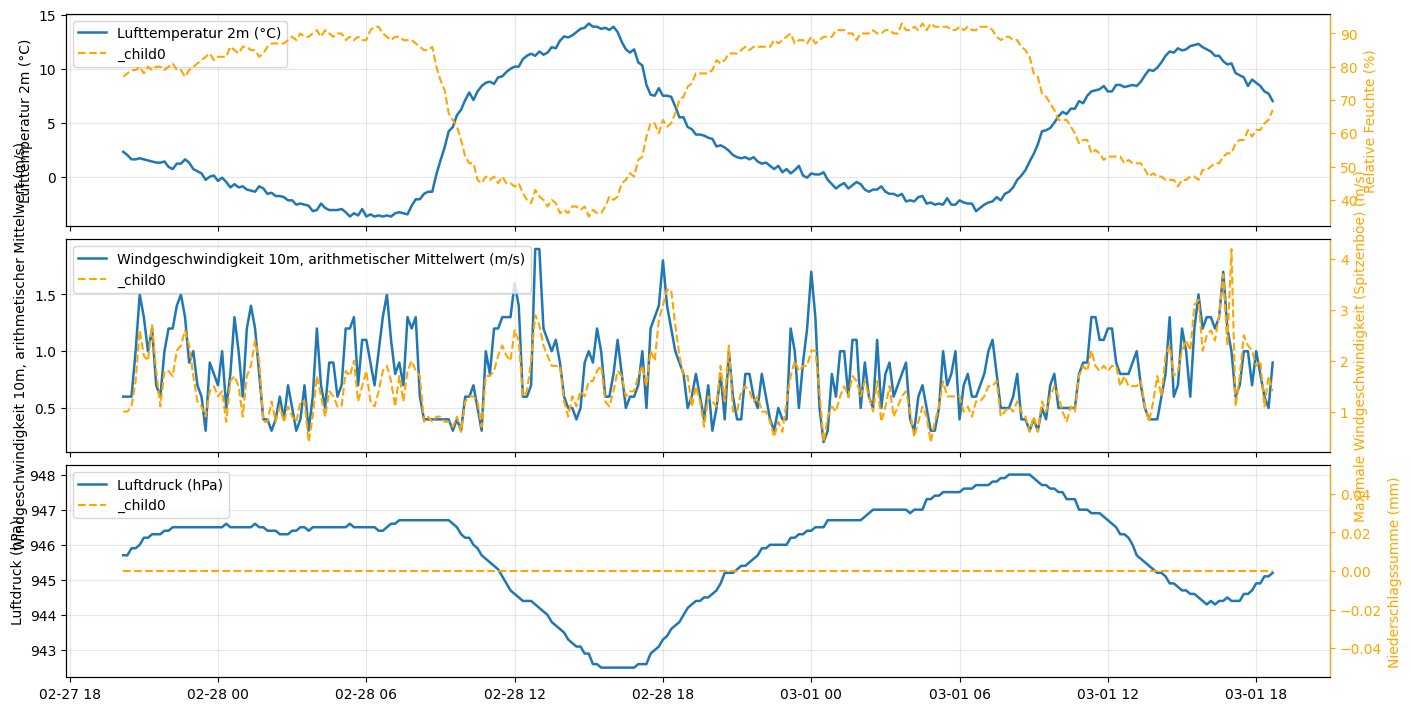

In [36]:
fig, ax = plot_dual_subplots(
    df,
    pairs=[
        ("Lufttemperatur 2m (°C)", "Relative Feuchte (%)"),
        ("Windgeschwindigkeit 10m, arithmetischer Mittelwert (m/s)", "Maximale Windgeschwindigkeit (Spitzenböe) (m/s)"),
        ("Luftdruck (hPa)", "Niederschlagssumme (mm)")
    ],
    figsize=(14, 7),
)

plt.show()